In [1]:
# plotting raw dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns

from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

#aesthetics
# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 600

def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))


count of -2 in there is:  0


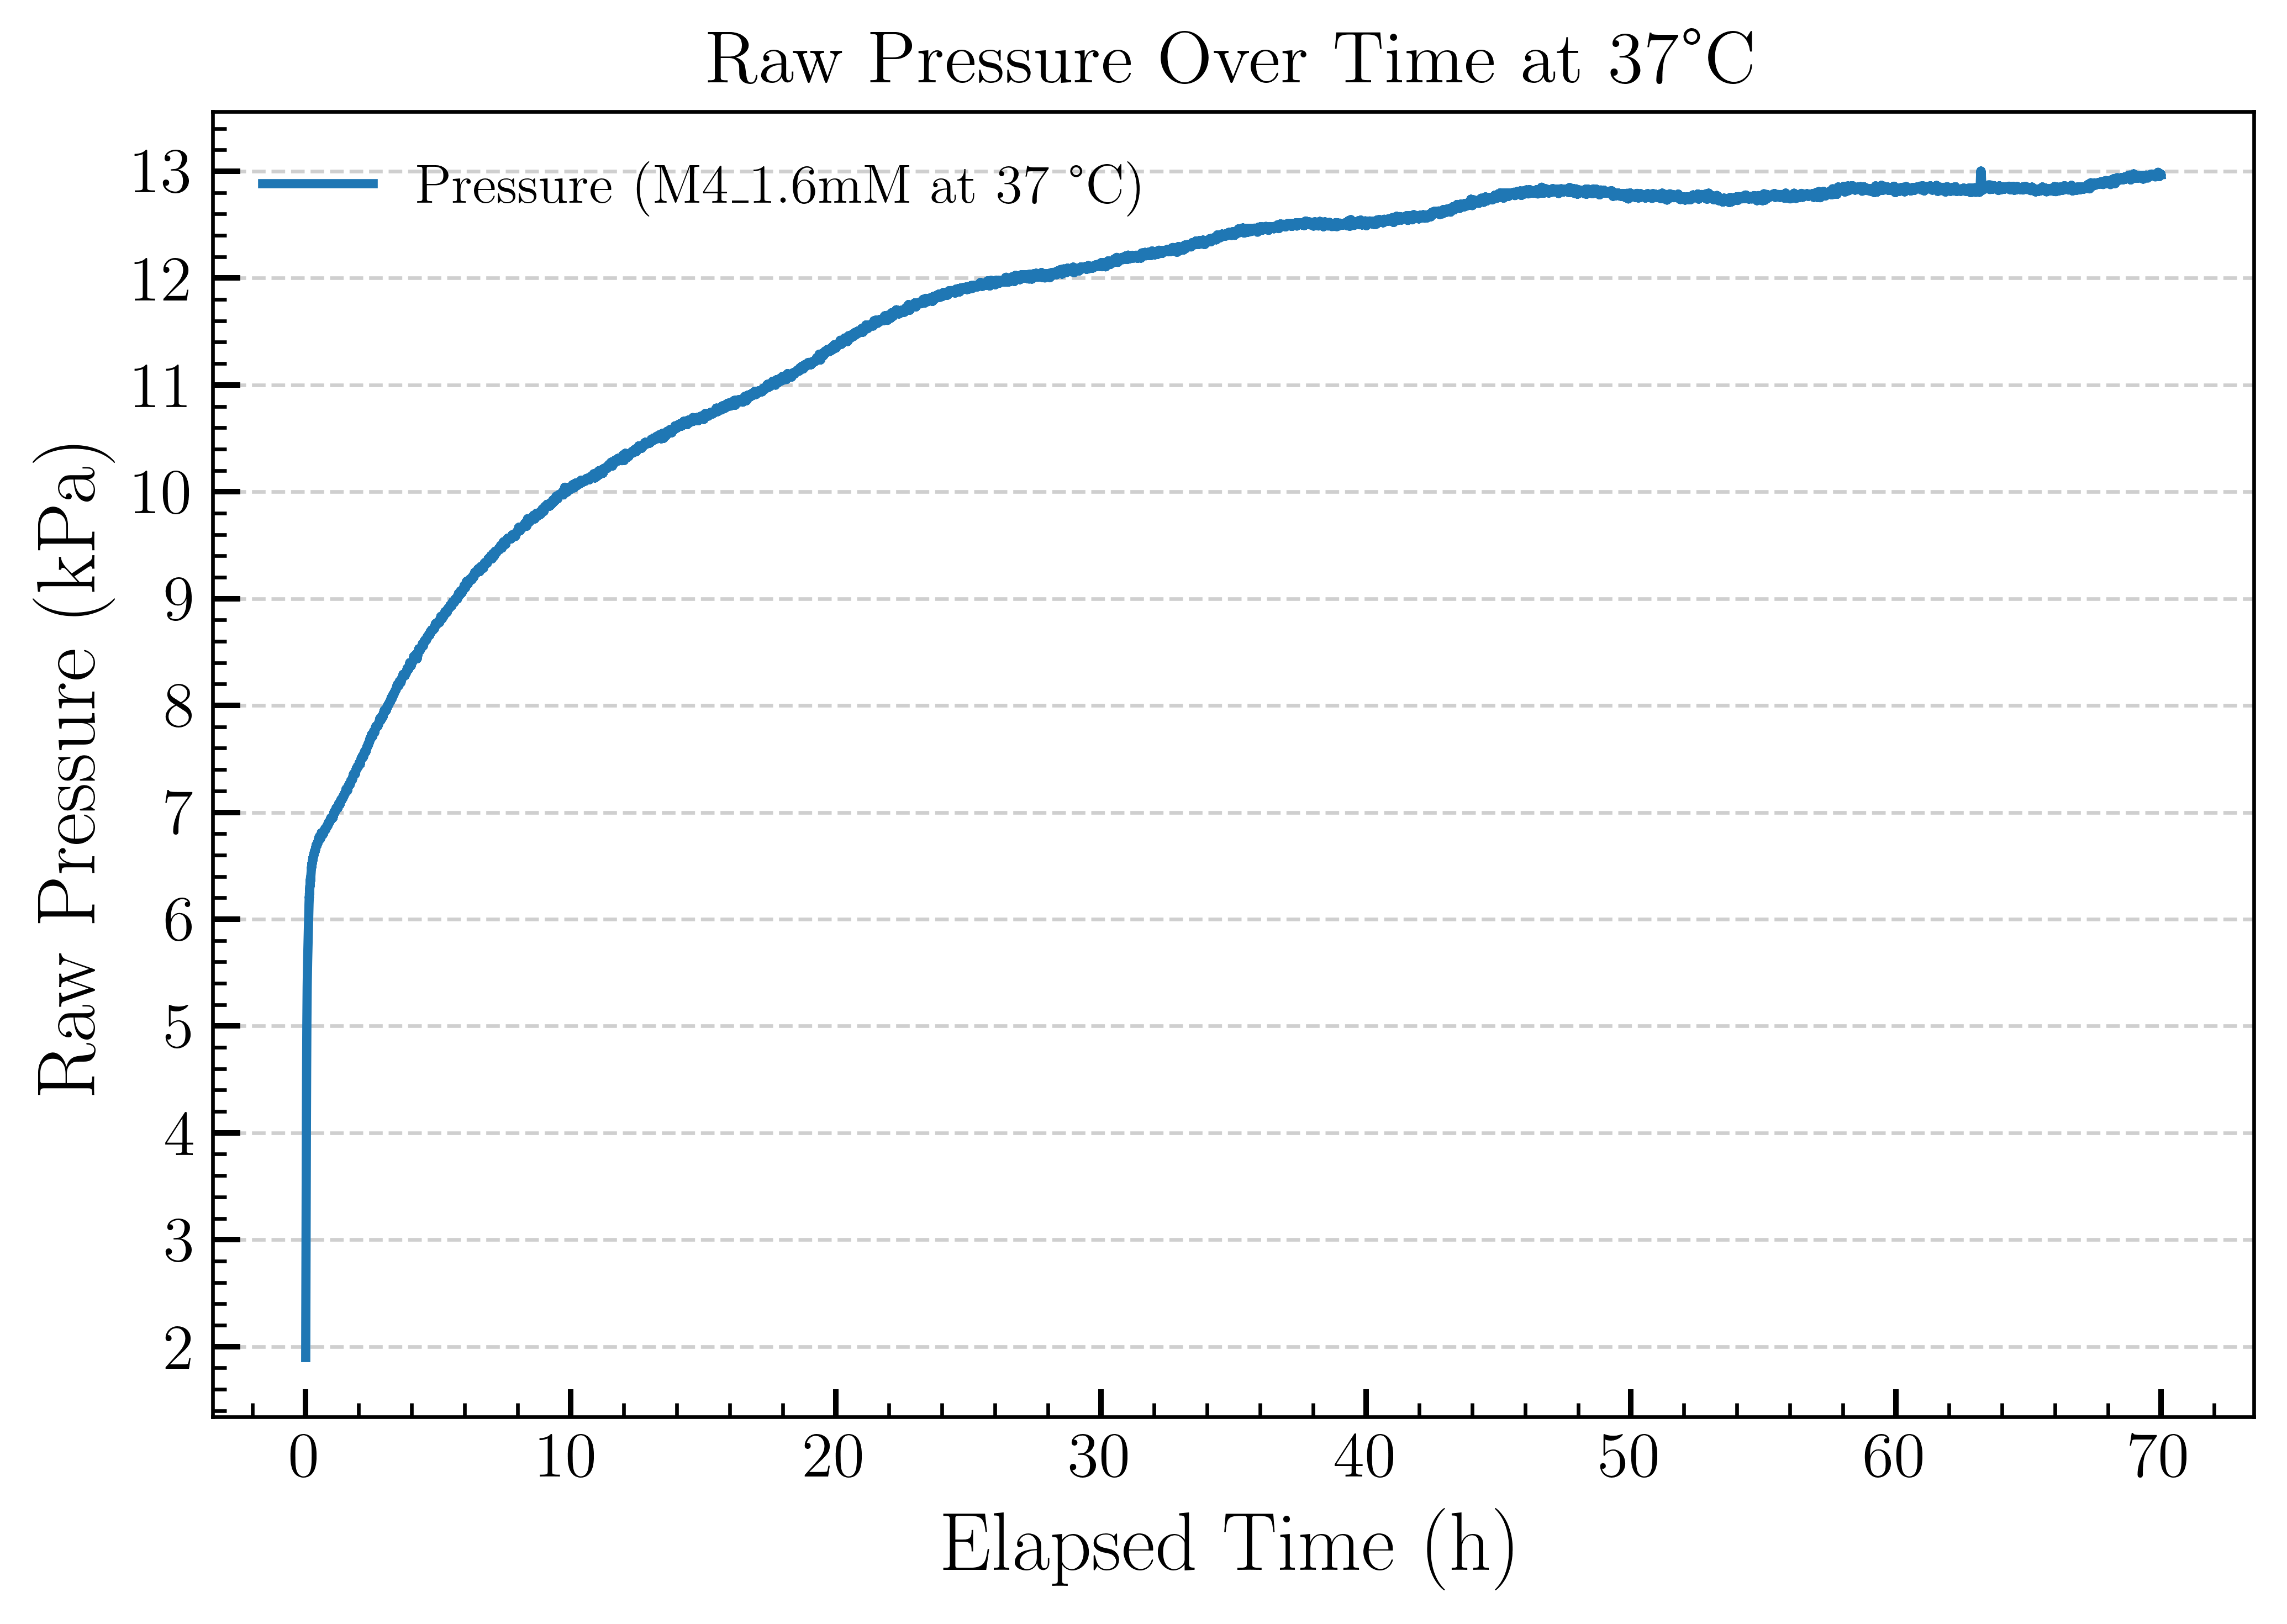

In [2]:
path = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\raw dataset\concatinated\merged_pressure_log.csv"
df_1 = pd.read_csv(path)

count = (df_1["ABP2-Sch1 (kPa)"] == -2).sum()
print("count of -2 in there is: ", count)

df_1 = df_1[df_1["Elapsed Time (hours)"] <= 70].reset_index(drop=True)



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_1["Elapsed Time (hours)"],
         df_1["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at 37 °C)')

ax1.set_title('Raw Pressure Over Time at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_37C_raw_pressure.png', dpi=dpi, bbox_inches='tight')
plt.show()

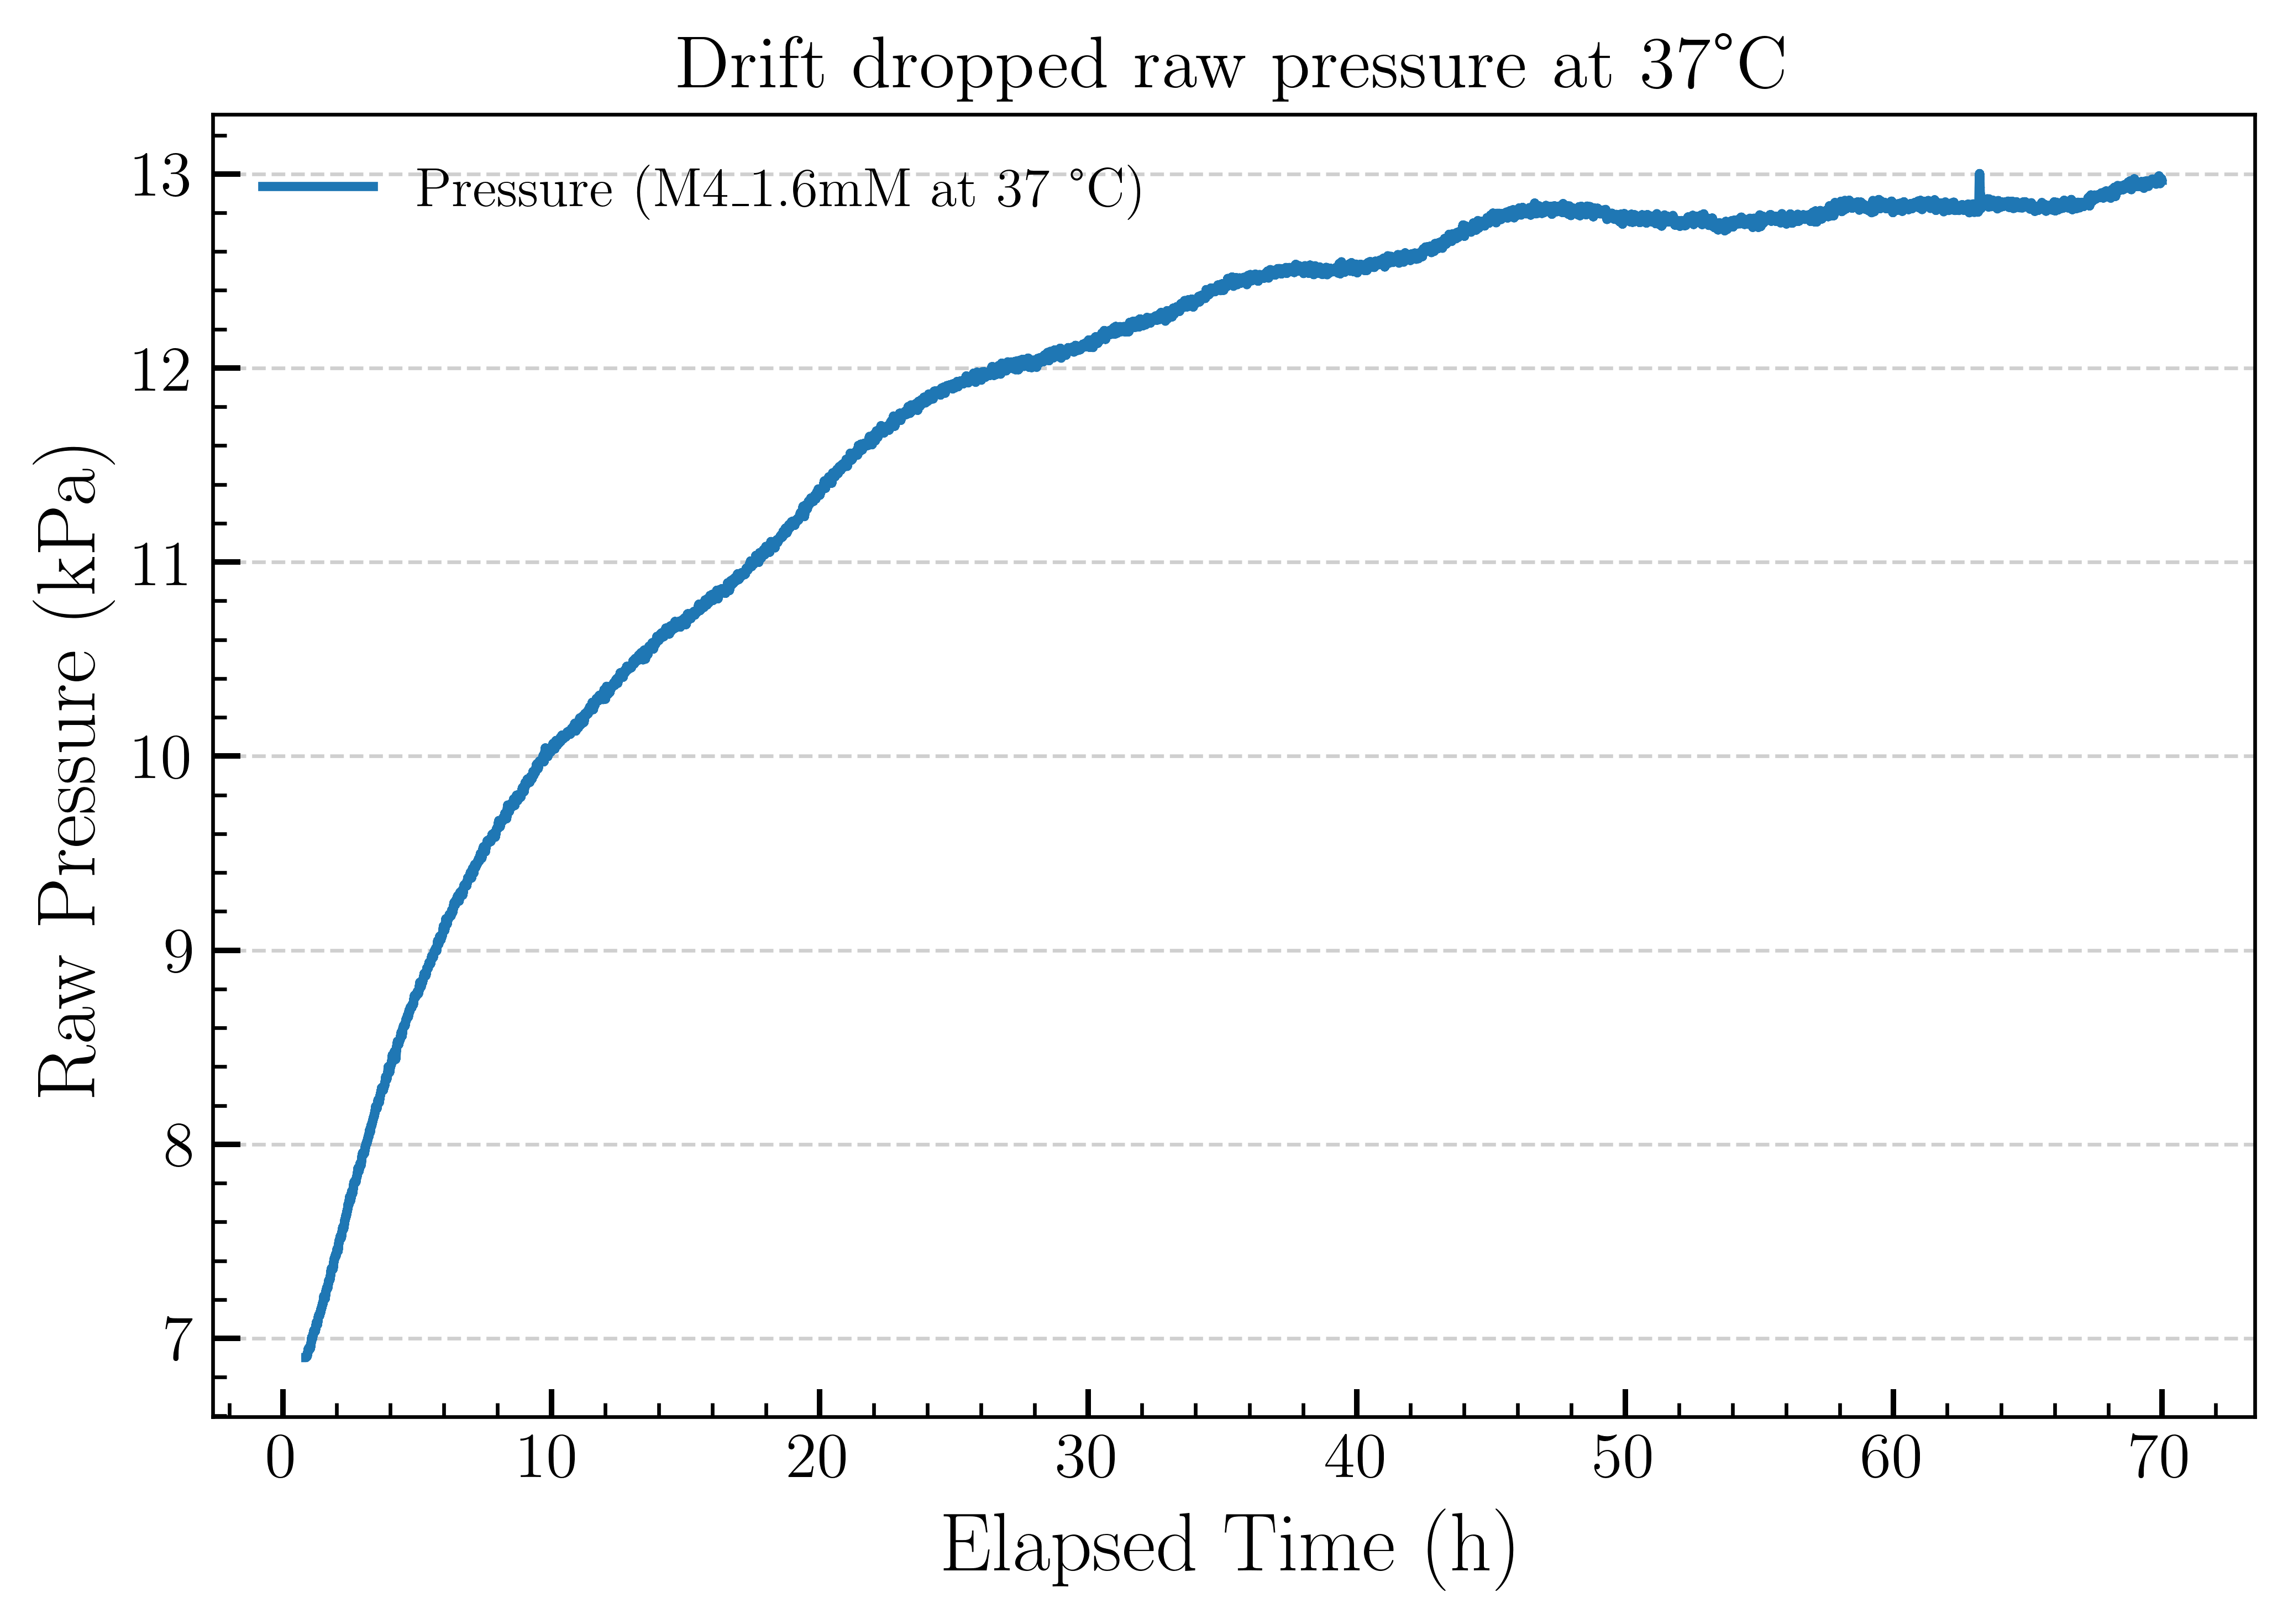

In [3]:
df_sensor = df_1[df_1["ABP2-Sch1 (kPa)"] > 6.9].reset_index(drop=True)
df_sensor = df_sensor[df_sensor["Elapsed Time (hours)"] <= 70].reset_index(drop=True)




fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at 37 °C)')

ax1.set_title('Drift dropped raw pressure at 37°C', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_37C_raw_pressure_drift_dropped.png', dpi=dpi, bbox_inches='tight')
plt.show()

pd.DataFrame.to_csv(df_sensor, r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\data files\sensor_drift_dropped.csv", index=False)

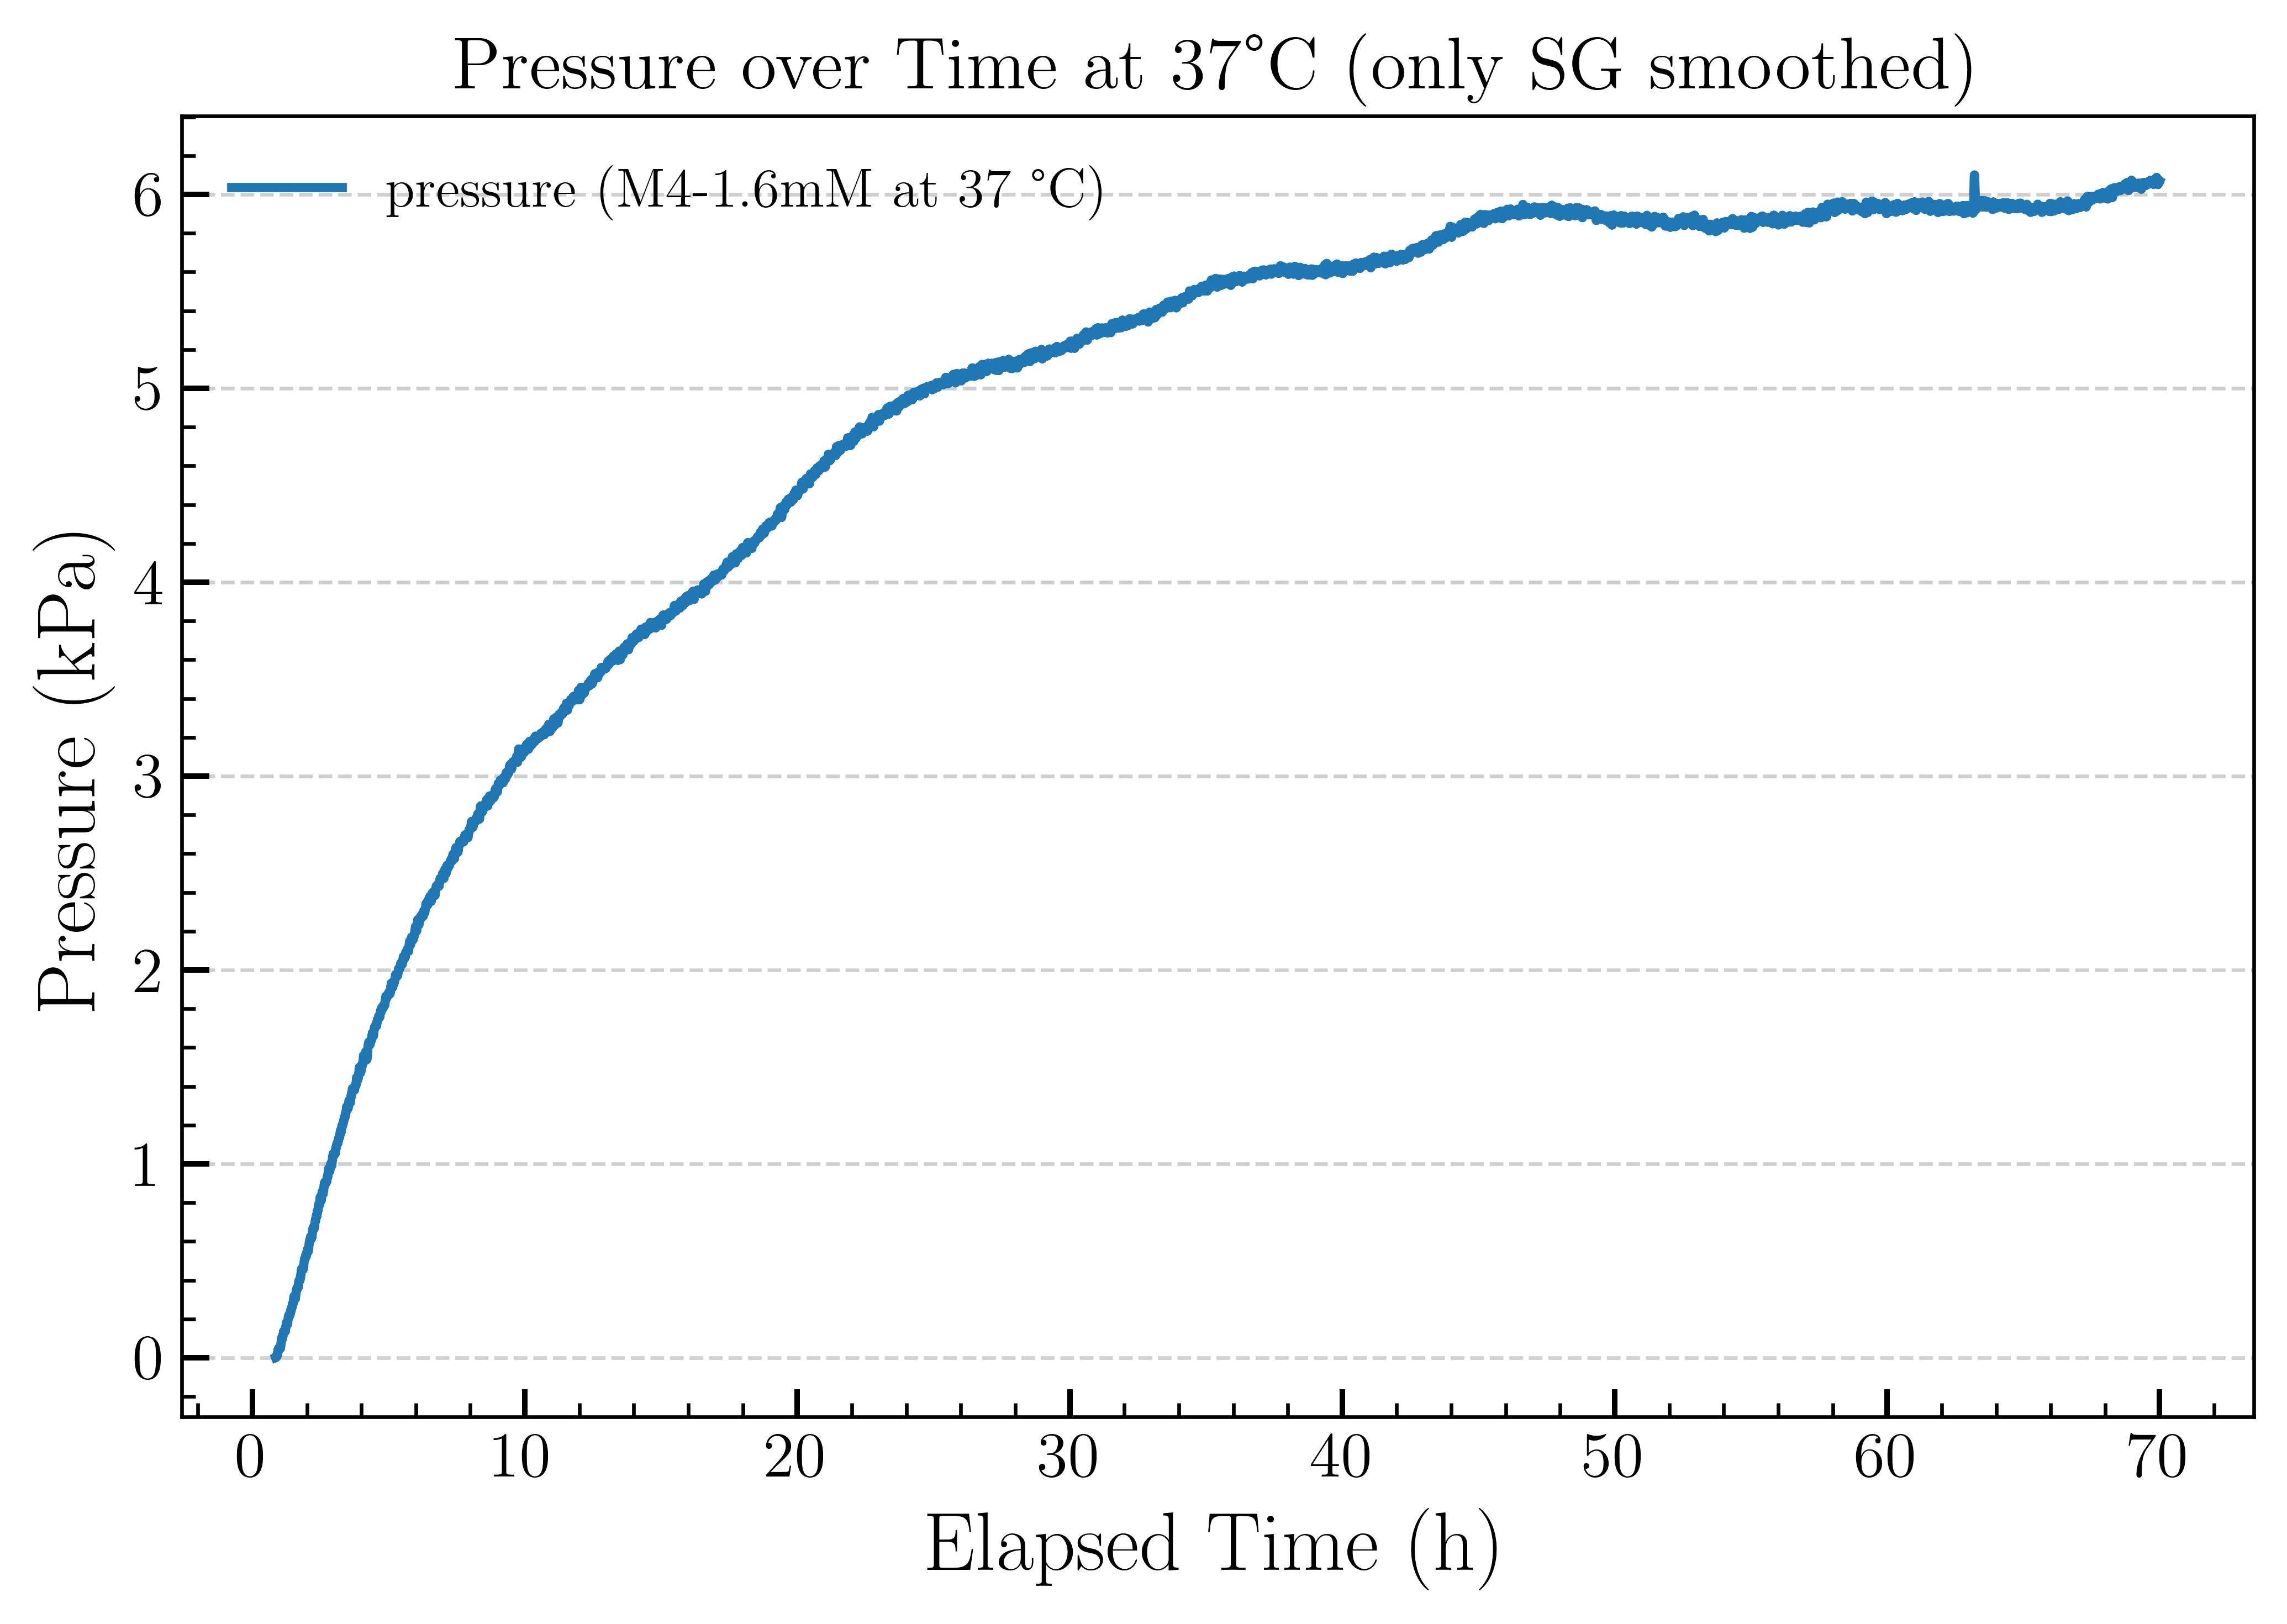

6.100477618648053


In [4]:
# Load data
new = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\data files\M4_1.6mM_37deg_O2_release_selfcrop.csv"

df_newraw = pd.read_csv(new)


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_newraw["Time (h)"],
         df_newraw["SG smoothed pressure (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'pressure (M4-1.6mM at 37 °C)')

ax1.set_title('Pressure over Time at 37°C (only SG smoothed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_37C_SG_smoothed_pressure.png', dpi=dpi, bbox_inches='tight')
plt.show()

print(max(df_newraw["SG smoothed pressure (kPa)"]))

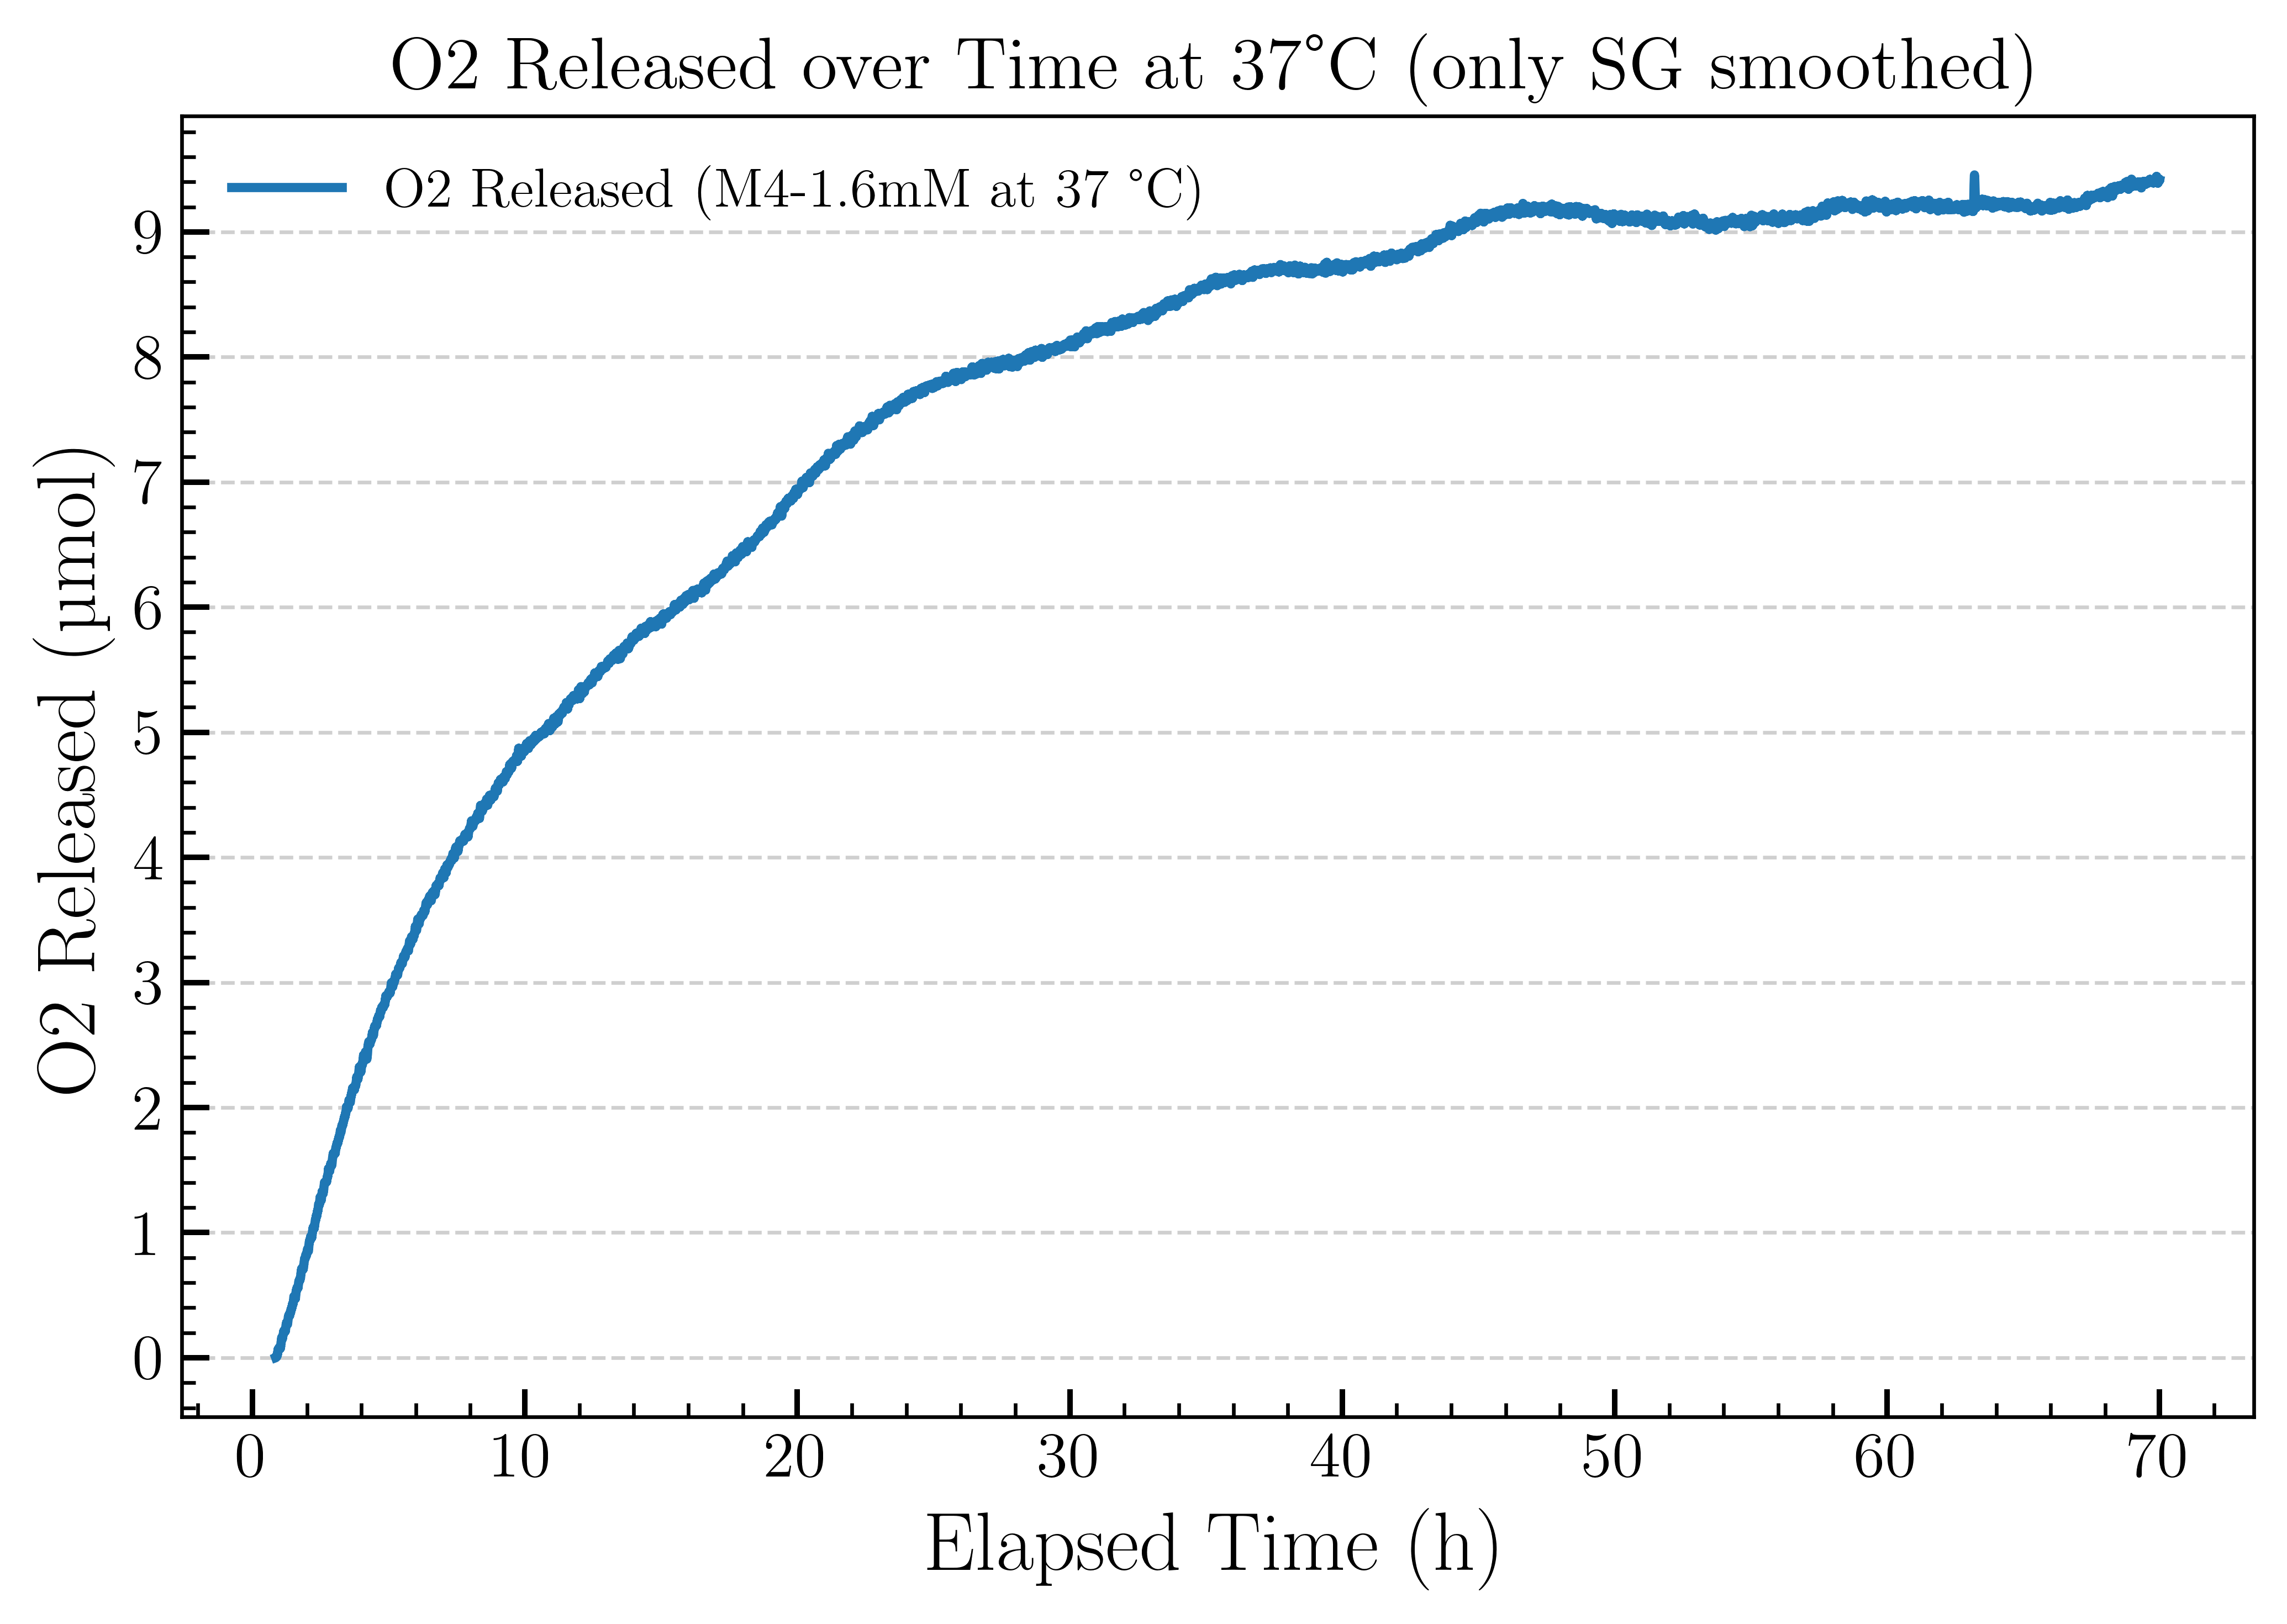

9.455310151271762


In [5]:
# Load data
new = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\37 C\data files\M4_1.6mM_37deg_O2_release_selfcrop.csv"

df_newraw = pd.read_csv(new)


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_newraw["Time (h)"],
         df_newraw["O2 Released (µmol) with SG"],
         lw=2.0, color="tab:blue",
         label=r'O2 Released (M4-1.6mM at 37 °C)')

ax1.set_title('O2 Released over Time at 37°C (only SG smoothed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="O2 Released (µmol)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_37C_SG_smoothed_O2_released.png', dpi=dpi, bbox_inches='tight')
plt.show()

print(max(df_newraw["O2 Released (µmol) with SG"]))